# Experiment 3 -- When priority matters and when depth matters

Compare the four designs of the paper (Figure 8) using the same empirical service calibration.
Here **importance** is operationalized by the welfare of priority-only versus
depth-only design. Equivalently, compare their welfare improvements over neither.
This comparison is not a causal decomposition of the joint improvement.

On the displayed arrival range $[0,4]$, depth-only is marginally better than
priority-only at very light load and briefly near $\lambda=1.5$; priority-only is
better elsewhere at moderate load; depth-only overtakes it again near capacity.
Priority alone achieves the joint design's welfare for $0.66\leq\lambda\leq0.90$.
The depth and sojourn snapshot uses $\lambda=1.5$, where the four designs assign
four different depth profiles and all of them serve every customer.

Delay sensitivities are **uniform on $[0.01,0.5]$**. This is an illustrative
population assumption, not an estimate from DeepSWE. All parameter choices and
checks are below.
The x-axis is arrival rate; it is not service rate or server capacity.

## Queueing model and optimization scope

Independent Poisson arrivals join one server. A served job draws its service
requirement from the **empirical distribution at its assigned depth**, independently
of delay sensitivity. Service requirements are proportional to historical token
cost, with the same common normalization as `DeepSWE_stats.ipynb`; they are not
measured seconds. Service value is the empirical binary success rate. A no-service
assignment has value, service time, and sojourn time zero.

With potential type arrival rates $\lambda_i$, set
$\rho_i=\lambda_i m_i$, $\rho=\sum_i\rho_i$, and
$R=\tfrac12\sum_i\lambda_i E[S_i^2]$. Reject assignments with $\rho\geq1$.
For FCFS, $w_i=m_i+R/(1-\rho)$ for served types. For nonpreemptive priority,

$$w_i=m_i+\frac{R}{(1-H_i)(1-H_i-\rho_i)},$$

where $H_i$ is the load of higher-priority classes. Welfare per unit time is
$W=\sum_i\lambda_i[V(d_i)-\theta_i w_i]$. No monetary cost is subtracted a
second time. These are **exact stationary calculations under the specified
queueing assumptions**, not queue simulations or an exponential approximation.

IC requires sojourn to be nonincreasing in $\theta$, **including excluded types**.
We also construct prices and check every pairwise deviation and the outside option.
The analysis follows the paper's transferable-price formulation; a new restriction
on prices would require re-solving the menu problem.

This notebook is self-contained. Run its cells from top to bottom; only the
saved files in `data/` are required. Calibration, queueing formulas, optimization,
plotting, and numerical checks are included below. No additional local Python
modules or API calls are needed. Snapshot checksums are checked on every run.

### What “optimal” means in this discretization

The population is approximated by 40 equal-mass types. Personalized
designs are optimized by exhaustively enumerating all
$\binom{45}{5}=1,221,759$ **nonincreasing depth assignments** across ascending
delay sensitivities. This includes exclusion of a high-$\theta$ tail.
For each assignment the optimal static nonpreemptive priority order is descending
$\theta_i/m_i$, which here equals descending $\theta_i$.

The result is an exact optimum **within this monotone policy class**, not a
certificate over all $6^{40}$ assignments. The paper's continuum theorem under
exponential/preemptive assumptions does not by itself certify this finite,
empirical, nonpreemptive calculation. Unrestricted one-type deviation checks and
a 20-versus-40-type comparison below are diagnostics, not proofs of a global
optimum or continuum convergence. The common-depth benchmarks are exhaustive over
their six choices. All statements about fine designs below use this explicit scope.

## Load the empirical calibration

All five depths use one common cost-to-time scaling factor. The loader verifies the saved data before computing service values and moments.


In [1]:
from pathlib import Path
from dataclasses import dataclass
from itertools import combinations, product, permutations
import hashlib
import json
import math

import numpy as np
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

# Launch from this folder, Code/, or the repository root.
ROOT = next((p for p in [Path.cwd(), Path.cwd() / 'Case Study DeepSWE',
                       Path.cwd() / 'Code/Case Study DeepSWE']
             if (p / 'data/manifest.json').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Launch from the notebook folder, Code/, or the repository root.')
RESULTS = ROOT / 'results'  # Figures used in the paper.

LABELS = np.array(['No service', 'low', 'medium', 'high', 'xhigh', 'max'])

COLORS = {'central': '#4c78a8', 'ic': '#e15759', 'joint': '#4c78a8',
          'depth': '#59a14f', 'priority': '#f28e2b', 'neither': '#777777'}


@dataclass
class Calibration:
    values: np.ndarray
    means: np.ndarray
    seconds: np.ndarray
    samples: dict
    scale: float
    provenance: dict


def load_calibration():
    """Recompute Sol's moments from checksum-verified trial-level snapshots."""
    manifest = json.loads((ROOT / 'data/manifest.json').read_text(encoding='utf-8'))
    records = []
    for entry in [manifest, *manifest['supplemental_files']]:
        raw = (ROOT / 'data' / entry['file']).read_bytes()
        if hashlib.sha256(raw).hexdigest() != entry['sha256']:
            raise ValueError(f"Snapshot checksum mismatch: {entry['file']}")
        part = json.loads(raw.decode('utf-8-sig'))
        assert len(part) == entry['record_count']
        records.extend(part)
    records = [r for r in records if r['model'] == 'gpt-5-6-sol']
    assert len(records) == 2260 and len({r['trial_name'] for r in records}) == 2260
    excluded = [r for r in records if not r['included_in_score']]
    assert len(excluded) == 4
    assert all(r['error_category'] == 'verifier_timeout' for r in excluded)
    scale = 1 / np.mean([r['cost_usd'] for r in records])
    values, means, seconds, samples = [0.], [0.], [0.], {}
    for effort in LABELS[1:]:
        rows = [r for r in records if r['reasoning_effort'] == effort]
        assert len(rows) == 452
        tasks, repeats = np.unique([r['task_name'] for r in rows], return_counts=True)
        assert len(tasks) == 113 and np.all(repeats == 4)
        times = scale * np.array([r['cost_usd'] for r in rows])
        assert np.all(np.isfinite(times)) and np.all(times > 0)
        samples[effort] = times
        values.append(np.mean([int(r['passed']) if r['included_in_score'] else 0 for r in rows]))
        means.append(times.mean())
        seconds.append(np.mean(times ** 2))
    assert np.isclose(np.concatenate(list(samples.values())).mean(), 1)
    provenance = {'model': 'gpt-5-6-sol', 'trials': len(records),
                  'timeout_as_incorrect': 4, 'cost_to_time': scale,
                  'snapshots': [{'file': e['file'], 'sha256': e['sha256']}
                                for e in [manifest, *manifest['supplemental_files']]]}
    return Calibration(np.array(values), np.array(means), np.array(seconds),
                       samples, scale, provenance)


cal = load_calibration()
print('GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.')
print(f'One common cost-to-time factor: {cal.scale:.8f}; pooled mean service time = 1.')
print(f"{'Depth':<12} {'Value':>9} {'E[S]':>10} {'E[S^2]':>10}")
for name, v, m, b in zip(LABELS, cal.values, cal.means, cal.seconds):
    print(f'{name:<12} {v:9.4f} {m:10.4f} {b:10.4f}')


GPT-5.6 Sol: 113 tasks x 4 trials x 5 efforts; four verifier timeouts counted incorrect.
One common cost-to-time factor: 0.25665713; pooled mean service time = 1.
Depth            Value       E[S]     E[S^2]
No service      0.0000     0.0000     0.0000
low             0.4535     0.2757     0.0943
medium          0.6106     0.4779     0.2973
high            0.6925     0.8899     1.0087
xhigh           0.7058     1.2082     1.8421
max             0.7235     2.1482     6.6322


## Queue evaluation and incentive compatibility

The functions below implement the formulas above. Excluded types remain in the incentive checks.


In [2]:
def evaluate(cal, depths, rates, theta, rule='priority', order=None):
    """Evaluate a stable static policy. Rates refer to potential arrivals.

    rule='priority': descending theta/E[S] unless an explicit order is supplied.
    rule='fcfs': a single FCFS queue. Excluded types have value and sojourn zero.
    Returns None for instability. Priority is nonpreemptive, FCFS within class.
    """
    depths = np.asarray(depths, dtype=int)
    rates, theta = np.asarray(rates, dtype=float), np.asarray(theta, dtype=float)
    assert depths.shape == rates.shape == theta.shape
    assert np.all((depths >= 0) & (depths <= 5))
    assert np.all(rates >= 0) and np.all(theta >= 0)
    m, b, v = cal.means[depths], cal.seconds[depths], cal.values[depths]
    rho = rates * m
    total = rho.sum()
    if total >= 1:
        return None
    residual = .5 * np.dot(rates, b)
    served = depths > 0
    w = np.zeros(len(depths))
    if rule == 'fcfs':
        w[served] = m[served] + residual / (1 - total)
    elif rule == 'priority':
        if order is None:
            idx = np.flatnonzero(served)
            order = idx[np.argsort(-theta[idx] / m[idx], kind='stable')]
        else:
            order = np.array([i for i in order if served[i]], dtype=int)
            assert sorted(order.tolist()) == np.flatnonzero(served).tolist()
        cumulative = np.cumsum(rho[order])
        previous = cumulative - rho[order]
        w[order] = m[order] + residual / ((1 - previous) * (1 - cumulative))
    else:
        raise ValueError('rule must be fcfs or priority')
    return {'welfare': float(np.dot(rates, v - theta * w)), 'sojourn': w,
            'depths': depths.copy(), 'rho': float(total), 'rule': rule}


def is_ic(theta, sojourn, tol=1e-10):
    """Single crossing: sojourn must be nonincreasing in delay sensitivity.

    Includes outside-option assignments. Assumes distinct theta, as in notebooks.
    """
    return bool(np.all(np.diff(np.asarray(sojourn)[np.argsort(theta)]) <= tol))


def price_certificate(cal, depths, theta, sojourn):
    """Construct prices and verify all pairwise IC and individual rationality.

    The highest-theta type gets zero surplus; discrete envelope increments use
    the next type's sojourn. Transfers follow the paper's unrestricted prices.
    A separate outside option is always included in the deviation check.
    """
    theta, sojourn = np.asarray(theta), np.asarray(sojourn)
    if not is_ic(theta, sojourn):
        raise ValueError('Sojourn allocation is not incentive compatible')
    idx = np.argsort(theta)
    t, w = theta[idx], sojourn[idx]
    surplus = np.zeros(len(t))
    for i in range(len(t) - 2, -1, -1):
        surplus[i] = surplus[i + 1] + (t[i + 1] - t[i]) * w[i + 1]
    prices = np.empty(len(t))
    prices[idx] = cal.values[np.asarray(depths)[idx]] - t * w - surplus
    utility = cal.values[depths][None, :] - theta[:, None] * sojourn[None, :] - prices[None, :]
    truthful = np.diag(utility)
    regret = np.maximum(0, np.maximum(utility.max(axis=1), 0) - truthful)
    assert regret.max() < 1e-9 and truthful.min() > -1e-9
    assert np.allclose(prices[np.asarray(depths) == 0], 0)
    return {'prices': prices, 'surplus': truthful, 'max_regret': float(regret.max())}


## Policy optimization

The optimizer enumerates the policy class stated above. Its definitions are included here so this notebook runs independently.


In [3]:
def level_counts(n):
    """Every monotone assignment, encoded by counts at depths 5,4,...,0."""
    bars = np.array(list(combinations(range(n + 5), 5)), dtype=np.int16)
    boundaries = np.column_stack([np.full(len(bars), -1), bars, np.full(len(bars), n + 5)])
    counts = (np.diff(boundaries, axis=1) - 1).astype(np.int16)
    assert len(counts) == math.comb(n + 5, 5) and np.all(counts.sum(axis=1) == n)
    return counts


def decode_counts(counts):
    return np.repeat(np.arange(5, -1, -1), counts)


class MonotoneOptimizer:
    """Exhaustive optimization within the monotone depth policy class.

    The equal-mass types are ordered by increasing theta. The priority order
    is consequently descending theta (also descending theta / mean service).
    This is NOT a global certificate over all 6**n unrestricted assignments.
    """
    def __init__(self, cal, theta, chunk=12000):
        self.cal, self.theta = cal, np.asarray(theta)
        assert np.all(np.diff(self.theta) > 0)
        self.n, self.chunk = len(theta), chunk
        self.counts = level_counts(self.n)

    def solve(self, arrivals, rules=('priority', 'fcfs')):
        arrivals = np.atleast_1d(arrivals)
        best = {rule: np.full(len(arrivals), -np.inf) for rule in rules}
        counts = {rule: np.zeros((len(arrivals), 6), dtype=int) for rule in rules}
        c, theta, n = self.cal, self.theta, self.n
        for start in range(0, len(self.counts), self.chunk):
            cc = self.counts[start:start + self.chunk]
            bounds = np.cumsum(cc, axis=1)[:, :-1]
            d = 5 - (np.arange(n)[None, :] >= bounds[:, :, None]).sum(axis=1)
            m, b, v = c.means[d], c.seconds[d], c.values[d]
            total_mean = m.mean(axis=1)
            residual_base = .5 * b.mean(axis=1)
            base_value = (v - theta * m).mean(axis=1)
            served_theta = np.where(d > 0, theta, 0)
            cumulative = np.cumsum(m[:, ::-1], axis=1)[:, ::-1] / n
            previous = cumulative - m / n
            for j, lam in enumerate(arrivals):
                stable = lam * total_mean < 1
                if not np.any(stable):
                    continue
                r = lam * residual_base[stable]
                for rule in rules:
                    if rule == 'priority':
                        denom = (1 - lam * previous[stable]) * (1 - lam * cumulative[stable])
                        delay = r * np.mean(served_theta[stable] / denom, axis=1)
                    elif rule == 'fcfs':
                        delay = r / (1 - lam * total_mean[stable]) * served_theta[stable].mean(axis=1)
                    else:
                        raise ValueError(rule)
                    scores = lam * (base_value[stable] - delay)
                    k = int(scores.argmax())
                    if scores[k] > best[rule][j]:
                        best[rule][j] = float(scores[k])
                        counts[rule][j] = cc[np.flatnonzero(stable)[k]]
        return {rule: {'welfare': best[rule],
                       'depths': np.array([decode_counts(cc) for cc in counts[rule]])}
                for rule in rules}


def common_depth_sweep(cal, theta, arrivals, rule):
    """Six common-depth options, including closure; all types share one depth."""
    values, assignments = [], []
    for lam in arrivals:
        options = [evaluate(cal, np.full(len(theta), d), np.full(len(theta), lam / len(theta)), theta, rule)
                   for d in range(6)]
        winner = max((x for x in options if x is not None), key=lambda x: x['welfare'])
        values.append(winner['welfare']); assignments.append(winner['depths'])
    return {'welfare': np.array(values), 'depths': np.array(assignments)}


def local_deviation_gain(cal, depths, lam, theta, rule='priority'):
    """Best single-type change among all depths (diagnostic, NOT a proof)."""
    rates = np.full(len(theta), lam / len(theta))
    baseline = evaluate(cal, depths, rates, theta, rule)['welfare']
    best = baseline
    for i, old in enumerate(depths):
        for d in range(6):
            if d == old:
                continue
            candidate = np.array(depths, copy=True); candidate[i] = d
            result = evaluate(cal, candidate, rates, theta, rule)
            if result is not None:
                best = max(best, result['welfare'])
    return max(0., best - baseline)


## Numerical checks

Check queue identities and compare the optimizer with direct scalar enumeration on a small instance before running the experiment.


In [4]:
# Independent M/M/1 check: exponential mean 2, arrival .2 => mean sojourn 2/(1-.4).
example = Calibration(np.array([0., 1.]), np.array([0., 2.]), np.array([0., 8.]), {}, 1., {})
for rule in ['fcfs', 'priority']:
    result = evaluate(example, [1, 0], [.2, 100.], [.3, .1], rule)
    np.testing.assert_allclose(result['sojourn'], [2 / .6, 0.])
    assert evaluate(example, [1], [.5], [.1], rule) is None

# Conservation of load-weighted waiting, and c-mu optimality among all six orders.
d = np.array([1, 3, 2])
rates, theta_check = np.array([.2, .25, .3]), np.array([.1, .05, .2])
rho = rates * cal.means[d]
residual = .5 * np.dot(rates, cal.seconds[d])
expected = residual * rho.sum() / (1 - rho.sum())
best = evaluate(cal, d, rates, theta_check)
for order in permutations(range(3)):
    result = evaluate(cal, d, rates, theta_check, order=order)
    assert np.isclose(np.dot(rho, result['sojourn'] - cal.means[d]), expected)
    assert best['welfare'] + 1e-12 >= result['welfare']
assert not is_ic([.12, .09], [1., 0.])  # Patient excluded, impatient served: not IC.
assert is_ic([.12, .09], [0., 1.])
print('Queue formula, stability, priority, and outside-option checks passed.')

# Check the batched optimizer against independently generated four-type assignments.
theta_check = np.array([.003, .01, .025, .07])
small_optimizer = MonotoneOptimizer(cal, theta_check, chunk=37)
assignments = [np.array(d) for d in product(range(6), repeat=4) if np.all(np.diff(d) <= 0)]
assert len(assignments) == len(small_optimizer.counts)
for lam_check in [.1, 2.8, 4.]:
    batched = small_optimizer.solve([lam_check])
    for rule in ['fcfs', 'priority']:
        scalar = [evaluate(cal, d, np.full(4, lam_check / 4), theta_check, rule) for d in assignments]
        optimum = max(r['welfare'] for r in scalar if r is not None)
        assert np.isclose(batched[rule]['welfare'][0], optimum, atol=1e-10)
print('Monotone optimizer agrees with independent scalar enumeration.')


Queue formula, stability, priority, and outside-option checks passed.
Monotone optimizer agrees with independent scalar enumeration.


## Figure style

Three separate panels with four design styles. Only the figures used in the paper
are saved, as PDFs in `results/`; numerical results are printed below.

In [5]:
RED = '#c0392b'
DESIGNS = {
    'joint': dict(color='#222222', linewidth=2.4, linestyle='-', label=r'Joint ($c\mu$ priority)'),
    'depth': dict(color='#1f77b4', linewidth=2.0, linestyle='-.', label='Depth only (FCFS)'),
    'priority': dict(color=RED, linewidth=2.0, linestyle='--', label=r'Priority only ($c\mu$ priority)'),
    'neither': dict(color='#2ca02c', linewidth=3.0, linestyle=':', label='Neither (FCFS)'),
}

def setup_style():
    plt.rcParams.update({'font.family': 'serif', 'font.size': 9, 'axes.labelsize': 10,
                         'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'axes.linewidth': .6, 'lines.linewidth': 1.5})

def paper_axis(xlabel, ylabel=None, depths=False, columns=2):
    figure, axis = plt.subplots(figsize=(7.2, 4.8))
    axis.set_xlabel(xlabel, fontsize=24)
    axis.tick_params(labelsize=18)
    axis.grid(axis='y', alpha=.18)
    if depths:
        axis.set_ylim(-.4, 5.5)
        axis.set_yticks(range(6), [f'$d_{k}$' for k in range(6)])
    if ylabel is not None:
        axis.set_ylabel(ylabel, fontsize=26, rotation=0, labelpad=18)
        axis.yaxis.set_label_coords(-.2, .5)
    figure.subplots_adjust(left=.21 if ylabel else .13, right=.96,
                           top=.82 if columns == 2 else .87, bottom=.21)
    return figure, axis

def paper_legend(axis, columns=2, fontsize=14):
    axis.legend(fontsize=fontsize, loc='lower center', bbox_to_anchor=(.5, 1.01),
                ncol=columns, frameon=True, edgecolor='#cccccc', framealpha=1.,
                handlelength=1.6, borderpad=.4, columnspacing=1.2)

def save_figure(figure, name):
    """Save a figure used in the paper as results/<name>.pdf, then display it."""
    RESULTS.mkdir(exist_ok=True)
    figure.savefig(RESULTS / f'{name}.pdf', metadata={'CreationDate': None})
    plt.show()
    plt.close(figure)

def shade_patient_advantage(axis, x, sojourn):
    # Shade where the patient type has the shorter sojourn time.
    mask = sojourn[:, 1] < sojourn[:, 0] - 1e-10
    for index, (left, right) in enumerate(intervals(x, mask)):
        axis.axvspan(left, right, color='#c7e9c0', alpha=.6, linewidth=0,
                     label=r'$w_2<w_1$' if index == 0 else None)

def regime_rows(x, result):
    states = list(zip(result['depths'][:, 0], result['depths'][:, 1], result['rules']))
    rows, start = [], 0
    for i in range(1, len(x) + 1):
        if i == len(x) or states[i] != states[start]:
            a, b, rule = states[start]
            rows.append({'left': x[start], 'right': x[i - 1],
                         'impatient_depth': a, 'patient_depth': b, 'rule': rule})
            start = i
    return rows


## Parameters, selection rationale, and limits

Use $n=40$ midpoint quantiles of $\theta\sim\mathrm{Unif}[0.01,0.5]$.

The welfare panel covers $\lambda\in[0,4]$; every design has zero welfare at
$\lambda=0$. Depth-only is marginally better than priority-only at very light
demand and briefly near $\lambda=1.5$, where priority-only must move every customer
from medium to low effort at once. Priority-only is better elsewhere at moderate
load, and depth-only is better again near capacity, where the common-depth designs
close while the personalized designs exclude the most delay-sensitive customers.
All crossover brackets are printed and exported.

The service-depth and sojourn snapshot uses $\lambda=1.5$, where the four designs
assign four different depth profiles and all serve every customer: neither gives
everyone low effort, priority-only gives everyone medium effort, and the two
personalized designs give medium effort to the most patient customers and low
effort to the rest. Joint design gives medium effort to more customers than
depth-only. These mechanisms are checked below.

The robustness section varies the distribution's upper endpoint and quantile power,
and compares 20 versus 40 types. These checks support local robustness, not
prevalence across arbitrary populations.

In [6]:
N = 40
THETA_LOW, THETA_HIGH, QUANTILE_POWER = .01, .5, 1.  # power 1: uniform

def sensitivity_quantiles(n, low=THETA_LOW, high=THETA_HIGH, power=QUANTILE_POWER):
    return low + (high - low) * ((np.arange(n) + .5) / n) ** power

THETA = sensitivity_quantiles(N)
SNAPSHOT = 1.5
ARRIVALS = np.unique(np.r_[np.round(np.arange(.02, 4.0001, .02), 6), SNAPSHOT])
setup_style()
optimizer = MonotoneOptimizer(cal, THETA)
optimized = optimizer.solve(ARRIVALS)
results = {'joint': optimized['priority'], 'depth': optimized['fcfs'],
           'priority': common_depth_sweep(cal, THETA, ARRIVALS, 'priority'),
           'neither': common_depth_sweep(cal, THETA, ARRIVALS, 'fcfs')}
for key in ['depth', 'priority', 'neither']:
    assert np.all(results['joint']['welfare'] + 1e-10 >= results[key]['welfare'])
priority_minus_depth = results['priority']['welfare'] - results['depth']['welfare']
assert np.all(priority_minus_depth != 0)
changes = np.flatnonzero(np.diff(np.sign(priority_minus_depth)))
assert len(changes) == 4 and priority_minus_depth[0] < 0 and priority_minus_depth[-1] < 0
CROSSOVER_BRACKETS = [ARRIVALS[k:k + 2] for k in changes]
same = np.isclose(results['joint']['welfare'], results['priority']['welfare'], rtol=0, atol=1e-12)
light = int(np.argmin(abs(ARRIVALS - .8)))
assert np.all(results['joint']['depths'][light] == 2)
assert np.isclose(results['joint']['welfare'][light], results['priority']['welfare'][light])
assert results['priority']['welfare'][light] > results['depth']['welfare'][light]
assert results['priority']['welfare'][-1] == results['neither']['welfare'][-1] == 0
print('Priority-only/depth-only crossover brackets:', [b.tolist() for b in CROSSOVER_BRACKETS])
print(f'Priority-only matches joint for {ARRIVALS[same].min():.2f} <= lambda <= {ARRIVALS[same].max():.2f}')
print('lambda     joint      depth   priority    neither')
for arrival in [.5, 1., SNAPSHOT, 2., 2.5, 3., 3.5, 4.]:
    j = int(np.argmin(abs(ARRIVALS - arrival)))
    print(f"{ARRIVALS[j]:5.2f} " + ' '.join(f"{results[k]['welfare'][j]:10.6f}" for k in DESIGNS))
for key in ['priority', 'neither']:
    closed = results[key]['welfare'] == 0
    print(f"{key}: closure begins at sampled arrival {ARRIVALS[closed][0]:.2f}")
print('Very-light-load ordering:')
for arrival in [.1, .3, .5]:
    j = int(np.argmin(abs(ARRIVALS - arrival)))
    print(f'lambda={ARRIVALS[j]:.2f}: priority minus depth={priority_minus_depth[j]:.6f}')

Priority-only/depth-only crossover brackets: [[0.42, 0.44], [1.48, 1.5], [1.62, 1.64], [3.18, 3.2]]
Priority-only matches joint for 0.66 <= lambda <= 0.90
lambda     joint      depth   priority    neither
 0.50   0.233669   0.232059   0.233009   0.231923
 1.00   0.431499   0.417642   0.431034   0.416139
 1.50   0.588674   0.548362   0.547398   0.528700
 2.00   0.712570   0.659209   0.686151   0.659209
 2.50   0.805338   0.733247   0.802707   0.716137
 3.00   0.870205   0.786734   0.842591   0.523423
 3.50   0.923131   0.830208   0.438675   0.000000
 4.00   0.967167   0.867273   0.000000   0.000000
priority: closure begins at sampled arrival 3.58
neither: closure begins at sampled arrival 3.26
Very-light-load ordering:
lambda=0.10: priority minus depth=-0.001134
lambda=0.30: priority minus depth=-0.001175
lambda=0.50: priority minus depth=0.000950


## Welfare


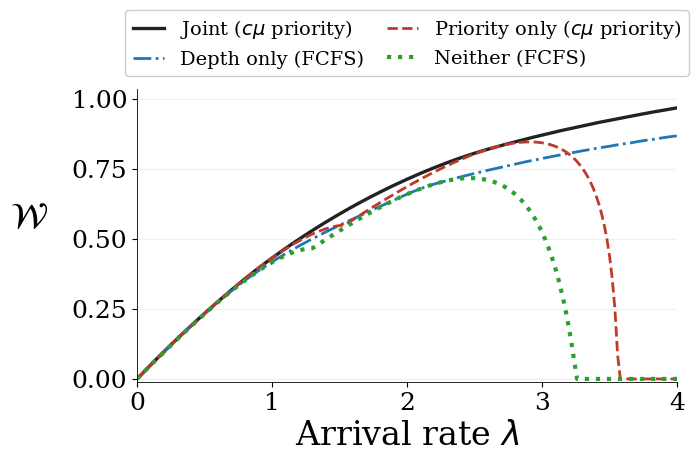

In [7]:
figure, axis = paper_axis(r'Arrival rate $\lambda$', ylabel=r'$\mathcal{W}$')
for key in ['joint', 'depth', 'priority', 'neither']:
    # Every design has zero welfare at lambda = 0.
    axis.plot(np.r_[0., ARRIVALS], np.r_[0., results[key]['welfare']], **DESIGNS[key])
axis.set_xlim(0, ARRIVALS[-1])
axis.set_ylim(-.01, 1.07 * results['joint']['welfare'].max())
paper_legend(axis)
save_figure(figure, 'continuous_type_load_welfare')

## Service depth at the selected arrival rate


joint: W=0.588674, rho=0.5955, counts={np.int64(1): np.int64(16), np.int64(2): np.int64(24)}
depth: W=0.548362, rho=0.5197, counts={np.int64(1): np.int64(26), np.int64(2): np.int64(14)}
priority: W=0.547398, rho=0.7169, counts={np.int64(2): np.int64(40)}
neither: W=0.528700, rho=0.4136, counts={np.int64(1): np.int64(40)}


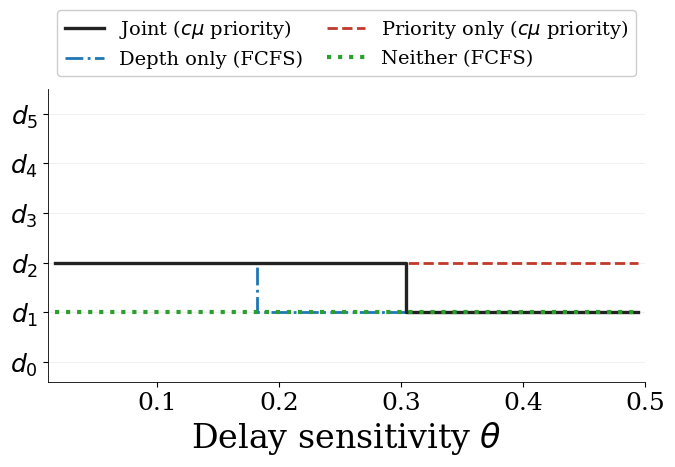

In [8]:
j = int(np.argmin(abs(ARRIVALS - SNAPSHOT)))
lam = ARRIVALS[j]
snapshot = {}
for key, result in results.items():
    d = result['depths'][j]
    rule = 'fcfs' if key in ['depth', 'neither'] else 'priority'
    row = evaluate(cal, d, np.full(N, lam / N), THETA, rule)
    snapshot[key] = row
    print(f"{key}: W={row['welfare']:.6f}, rho={row['rho']:.4f}, "
          f"counts={dict(zip(*np.unique(d, return_counts=True)))}")
assert len({tuple(row['depths']) for row in snapshot.values()}) == 4
assert all(np.all(row['depths'] > 0) for row in snapshot.values())
assert np.all(snapshot['priority']['depths'] == 2) and np.all(snapshot['neither']['depths'] == 1)
assert set(snapshot['joint']['depths']) == set(snapshot['depth']['depths']) == {1, 2}
assert np.sum(snapshot['joint']['depths'] == 2) > np.sum(snapshot['depth']['depths'] == 2)
assert all(snapshot['joint']['welfare'] > snapshot[key]['welfare'] for key in ['depth', 'priority', 'neither'])
figure, axis = paper_axis(r'Delay sensitivity $\theta$', depths=True)
for key in ['priority', 'depth', 'joint', 'neither']:
    axis.step(THETA, snapshot[key]['depths'], where='mid', **DESIGNS[key])
axis.set_xlim(THETA_LOW, THETA_HIGH)
handles = [plt.Line2D([], [], **DESIGNS[key]) for key in DESIGNS]
axis.legend(handles=handles, fontsize=14, loc='lower center', bbox_to_anchor=(.5, 1.01),
            ncol=2, frameon=True, edgecolor='#cccccc', framealpha=1., columnspacing=1.2)
save_figure(figure, 'continuous_type_load_depth')

## Sojourn time at the same arrival rate

Every design serves every customer at this snapshot. The FCFS designs give a
sojourn that depends only on the assigned depth; the priority designs give longer
sojourns to more patient customers. Priority-only gives everyone medium effort,
which produces the longest sojourns for patient customers; joint design avoids
part of this congestion by giving low effort to the most delay-sensitive customers.

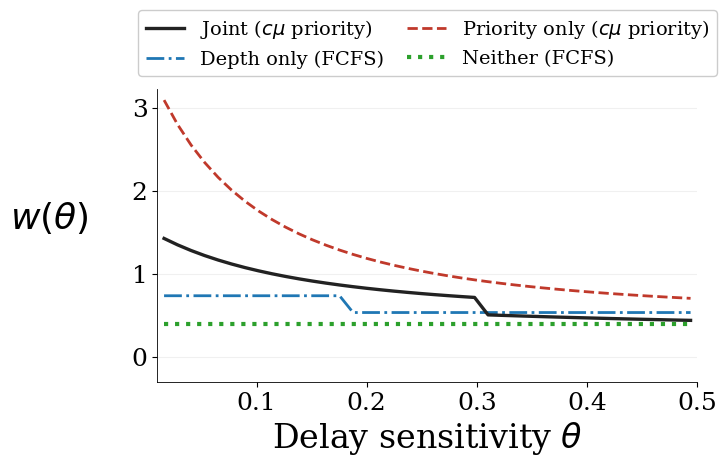

In [9]:
figure, axis = paper_axis(r'Delay sensitivity $\theta$', ylabel=r'$w(\theta)$')
for key in ['priority', 'depth', 'joint', 'neither']:
    # Excluded customers have zero sojourn time.
    axis.plot(THETA, snapshot[key]['sojourn'], **DESIGNS[key])
axis.set_xlim(THETA_LOW, THETA_HIGH)
axis.set_ylim(-.3, None)
axis.legend(handles=handles, fontsize=14, loc='lower center', bbox_to_anchor=(.5, 1.01),
            ncol=2, frameon=True, edgecolor='#cccccc', framealpha=1., columnspacing=1.2)
save_figure(figure, 'continuous_type_load_sojourn')

## Verification

Each winning allocation is reevaluated with the scalar queue formulas. IC prices
are checked for joint design, and unrestricted single-type deviations are tested.
These are diagnostics beyond the exact monotone search, not an unrestricted
global-optimality certificate. The discretization comparison is reported separately.


In [10]:
max_gain = max_regret = 0.
for j, lam in enumerate(ARRIVALS):
    for key, result in results.items():
        d = result['depths'][j]
        rule = 'fcfs' if key in ['depth', 'neither'] else 'priority'
        row = evaluate(cal, d, np.full(N, lam / N), THETA, rule)
        assert np.isclose(row['welfare'], result['welfare'][j], atol=1e-10)
        if key in ['joint', 'depth']:
            max_gain = max(max_gain, local_deviation_gain(cal, d, lam, THETA, rule))
        if key == 'joint':
            max_regret = max(max_regret, price_certificate(cal, d, THETA, row['sojourn'])['max_regret'])
assert max_gain < 1e-9

check_loads = np.array([1., SNAPSHOT, 2., 3., 3.8])
coarse = MonotoneOptimizer(cal, sensitivity_quantiles(20)).solve(check_loads, rules=('priority',))['priority']
for i, arrival in enumerate(check_loads):
    j = int(np.argmin(abs(ARRIVALS - arrival)))
    w20, w40 = coarse['welfare'][i], results['joint']['welfare'][j]
    print(f'lambda={arrival:.2f}: 20/40-type relative welfare difference={abs(w40-w20)/w40:.2%}')

# Local parameter robustness is separate from the full 40-type baseline.
robust_loads = np.array([1., 3.8])
for high in [.45, .50, .55]:
    for power in [.8, 1., 1.2]:
        theta_test = sensitivity_quantiles(20, high=high, power=power)
        dd = MonotoneOptimizer(cal, theta_test).solve(robust_loads, rules=('fcfs',))['fcfs']['welfare']
        pp = common_depth_sweep(cal, theta_test, robust_loads, 'priority')['welfare']
        assert pp[0] > dd[0] and pp[-1] < dd[-1]
print('All nine distribution perturbations preserve priority > depth at lambda=1 and depth > priority at lambda=3.8.')
print(f'Maximum IC deviation={max_regret:.2e}; single-type welfare improvement={max_gain:.2e}')


lambda=1.00: 20/40-type relative welfare difference=0.02%
lambda=1.50: 20/40-type relative welfare difference=0.02%
lambda=2.00: 20/40-type relative welfare difference=0.05%
lambda=3.00: 20/40-type relative welfare difference=0.09%
lambda=3.80: 20/40-type relative welfare difference=0.14%
All nine distribution perturbations preserve priority > depth at lambda=1 and depth > priority at lambda=3.8.
Maximum IC deviation=1.11e-16; single-type welfare improvement=0.00e+00
